# Report 4: Environmental Perturbations for the Spacecraft Model

Gravity gradient torque, atmospheric drag (exponential atmosphere, rotating Earth), and solar radiation pressure match the Lecture 13 treatment: drag and SRP use projected plate area when enabled; GG uses the standard \( \tau \propto 1/r^3 \) rigid-body approximation in [environmental_perturbations.jl](environmental_perturbations.jl).

Downstream actuator sizing compares disturbances to **ADCS4 Section 12**: BCT **XACT-50** / **RWP050** wheels (rated **6 mN·m** peak torque and **50 mN·m·s** momentum per wheel axis) plus a short note on **torque rods** (\(|m_c| \leq 0.1\,\mathrm{A·m^2}\)). We also retain the safe-mode rotor reference **`H_r`** from the gyrostat design for qualitative dump cadence alongside per-wheel saturation.

## HW4 §2 — Environmental torques (assignment goals)

Keep the write-up and simulations aligned with these points:

**Model**
- Include **gravity gradient torque** in the spacecraft dynamics analysis.
- Include **exactly one** of **atmospheric drag** *or* **solar radiation pressure** as the second environmental torque, with a **clear orbit-based justification** for the choice.
- **Simulate several orbits**, comparing behavior **with vs without** each perturbation (turn perturbations on/off in the propagator or equivalent).

**Analysis**
1. **Peak torque:** maximum magnitude of gravity-gradient torque and of the chosen second torque.
2. **Averaging / momentum:** orbit-averaged torques; **maximum accumulated angular-momentum change over a 24 h day** from these effects.
3. **Control implications:** what this means for actuators and ACS (e.g. **momentum dumping** cadence vs wheel / rod limits).

*Notebook status (for your report):* **LEO (~480 km)** — **drag** is the chosen second torque (not SRP) in the **coupled propagator** below; SRP remains only in earlier analytic cells. Torque magnitudes, orbit averages, 1-day \(|\Delta \mathbf H|\) estimates, actuator comparison, and **several-orbit** coupled runs with GG/drag toggled are in this notebook.

In [13]:
using LinearAlgebra
using StaticArrays
using Random
using PythonPlot

# Load local .jl files (same folder as this notebook — set Jupyter cwd here if includes fail).
include("safe_mode_gyrostat.jl")
include("environmental_perturbations.jl")

# `EarthEnvironment` / `Spacecraft*` live in module `EnvironmentalPerturbations` (not an external package).
# Run this entire cell once after each kernel restart before any cell that calls `EarthEnvironment()`.
using .EnvironmentalPerturbations: EarthEnvironment,
    SpacecraftAeroProperties,
    SpacecraftSRPProperties,
    quat_to_dcm_body_to_inertial,
    atmospheric_density_exponential,
    relative_atmosphere_velocity,
    gravity_gradient_torque,
    atmospheric_drag_force,
    atmospheric_drag_torque,
    solar_radiation_pressure_force,
    solar_radiation_pressure_torque,
    environmental_wrench,
    environmental_wrench_from_km_state

include("orbit_gyrostat_environmental.jl")

## Model Setup

These helper functions reproduce the same nominal orbit and initial attitude setup used in the current simulation scripts.

### ADCS4 §12 actuator reference (abbrev.)

- Three **RWP050** reaction wheels aligned with body axes (**\( B_w = I_3 \)**): **maximum torque \(= 6~\mathrm{mN\cdot m}\)** per wheel, **maximum angular momentum \(= 50~\mathrm{mN\cdot m\cdot s}\)** saturated **per wheel / per axis** (orthogonal mounts; total vector momentum is bounded by Euclidean norm \(\leq \sqrt{3}\cdot 50~\mathrm{mN\cdot m\cdot s}\)).
- Three magnetic torque rods: **\(|m_{c,i}| \leq 0.1~\mathrm{A\cdot m^2}\)** producing **\( \tau_c = m_c\times B \)**; instantaneous torque is **perpendicular** to Earth’s magnetic field \(\mathbf B\) in body frame, so desaturation is time-varying via orbit-attitude \(\mathbf B(t)\) (only noted here; not propagated in disturbance-only cells).

In [14]:
function rotation_quat_between(a::SVector{3,Float64}, b::SVector{3,Float64})
    ua = normalize(a)
    ub = normalize(b)
    c = dot(ua, ub)
    if c >= 0.999999
        return @SVector [1.0, 0.0, 0.0, 0.0]
    elseif c <= -0.999999
        v = abs(ua[1]) < 0.9 ? SVector(1.0, 0.0, 0.0) :
            abs(ua[2]) < 0.9 ? SVector(0.0, 1.0, 0.0) : SVector(0.0, 0.0, 1.0)
        axis = normalize(cross(ua, v))
        return SVector{4,Float64}(0.0, axis[1], axis[2], axis[3])
    else
        axis = normalize(cross(ua, ub))
        angle = acos(clamp(c, -1.0, 1.0))
        qv = axis * sin(angle / 2)
        return @SVector [cos(angle / 2), qv[1], qv[2], qv[3]]
    end
end

function coe_to_eci(a_km, e, inc, raan, argp, nu)
    mu = 398600.4418
    p = a_km * (1 - e^2)
    rn = p / (1 + e * cos(nu))
    r_pqw = rn .* @SVector [cos(nu), sin(nu), 0.0]
    v_pqw = sqrt(mu / p) .* @SVector [-sin(nu), e + cos(nu), 0.0]

    cr, sr = cos(raan), sin(raan)
    ci, si = cos(inc), sin(inc)
    cp, sp = cos(argp), sin(argp)
    R = @SMatrix [
        cr * cp - sr * ci * sp   -cr * sp - sr * ci * cp    sr * si
        sr * cp + cr * ci * sp   -sr * sp + cr * ci * cp   -cr * si
        si * sp                   si * cp                    ci
    ]
    return R * r_pqw, R * v_pqw
end

function compute_sso_inclination(altitude_km)
    mu = 398600.4418
    re = 6378.1363
    j2 = 1.08262668e-3
    omega_dot = 0.985647 * (pi / 180) / 86400
    a = re + altitude_km
    n = sqrt(mu / a^3)
    return acos(clamp(omega_dot / (-1.5 * j2 * n * (re / a)^2), -1.0, 1.0))
end

compute_sso_inclination (generic function with 1 method)

In [15]:

Random.seed!(12345)

I_body = @SMatrix [
    0.249  0.0    0.0
    0.0    0.187  0.02
    0.0    0.02   0.148
]

e_panel = @SVector [0.0, 1.0, 0.0]
omega_des = rpm2rad(10.0)
w_des = omega_des .* e_panel

I_pert = perturb_inertia(I_body; sig_eig=0.03, sig_rot=deg2rad(2.0))
H_r, I_rotor_eff = required_rotor_momentum(I_pert, e_panel; ratio=1.2, omega=omega_des)

alt_km = 480.0
re_km = 6378.1363
a_km = re_km + alt_km
inc = compute_sso_inclination(alt_km)
r0_km, v0_kmps = coe_to_eci(a_km, 0.0, inc, 0.0, 0.0, 0.0)

sun_vec_eci = @SVector [1.0, 0.0, 0.0]
q0_orbit = rotation_quat_between(e_panel, sun_vec_eci)

env = EarthEnvironment()
aero = SpacecraftAeroProperties(
    Cd=2.2,
    area_m2=0.03,
    mass_kg=12.0,
    area_normal_body=e_panel,
    center_of_pressure_body_m=SVector(0.02, 0.0, 0.0)
)
srp = SpacecraftSRPProperties(
    Cr=1.3,
    area_m2=0.03,
    area_normal_body=e_panel,
    center_of_pressure_body_m=SVector(0.02, 0.0, 0.0),
    sun_distance_au=1.0,
    eclipse=false
)

#BCT RWP050 (XACT-50) nominal limits
const tau_wheel_max_nm = 6e-3        # max motor torque per wheel [N·m]
const h_wheel_max_nms_per_axis = 50e-3   # saturation per wheel axis [N·m·s]
const n_wheels = 3
const h_wheel_sphere_bound_nms = sqrt(n_wheels) * h_wheel_max_nms_per_axis  # |rho| loose upper norm if each axis saturated
println("omega_des = $(round(omega_des, digits=6)) rad/s")
println("H_r (safe-mode gyrostat storage ref) = $(round(H_r, digits=6)) N*m*s")
println("RWP050: tau_wheel_max = $(tau_wheel_max_nm) N*m, h_wheel_max per axis = $(h_wheel_max_nms_per_axis) N*m*s")
println("Nominal altitude = $(alt_km) km")

omega_des = 1.047198 rad/s
H_r (safe-mode gyrostat storage ref) = 0.113034 N*m*s
RWP050: tau_wheel_max = 0.006 N*m, h_wheel_max per axis = 0.05 N*m*s
Nominal altitude = 480.0 km


## Environmental Perturbation Evaluation

The next block evaluates each perturbation independently using the current model state convention. This is a single-state check at the initial orbit condition, so it is useful for verifying units, directions, and rough force and torque scales before we move to an orbit-wide analysis.

In [16]:
r0_m = 1000.0 .* r0_km
v0_mps = 1000.0 .* v0_kmps

tau_gg = gravity_gradient_torque(I_pert, q0_orbit, r0_m)
F_drag = atmospheric_drag_force(r0_m, v0_mps, q0_orbit, aero; env=env)
tau_drag = atmospheric_drag_torque(r0_m, v0_mps, q0_orbit, aero; env=env)
F_srp = solar_radiation_pressure_force(q0_orbit, sun_vec_eci, srp; env=env)
tau_srp = solar_radiation_pressure_torque(q0_orbit, sun_vec_eci, srp; env=env)

wrench_all = environmental_wrench(
    I_pert,
    q0_orbit,
    r0_m,
    v0_mps;
    sun_eci_m=sun_vec_eci,
    env=env,
    aero=aero,
    srp=srp,
    include_gravity_gradient=true,
    include_drag=true,
    include_srp=true
)

println("gravity gradient torque [N*m] = ", tau_gg)
println("atmospheric drag force [N] = ", F_drag)
println("atmospheric drag torque [N*m] = ", tau_drag)
println("solar radiation pressure force [N] = ", F_srp)
println("solar radiation pressure torque [N*m] = ", tau_srp)
println("combined environmental force [N] = ", wrench_all.force_eci_N)
println("combined environmental torque [N*m] = ", wrench_all.torque_body_Nm)

gravity gradient torque [N*m] = [5.648188350606304e-8, -1.254149750852541e-23, -2.277833242162833e-9]
atmospheric drag force [N] = [-0.0, 6.862661835964995e-23, -3.5245809525979607e-22]
atmospheric drag torque [N*m] = [-0.0, 7.049161905195921e-24, 3.0476340722018746e-40]
solar radiation pressure force [N] = [-1.7784e-7, -0.0, -0.0]
solar radiation pressure torque [N*m] = [0.0, -0.0, -3.5568000000000004e-9]
combined environmental force [N] = [-1.7784e-7, 6.862661835964995e-23, -3.5245809525979607e-22]
combined environmental torque [N*m] = [5.648188350606304e-8, -5.492335603329489e-24, -5.834633242162833e-9]


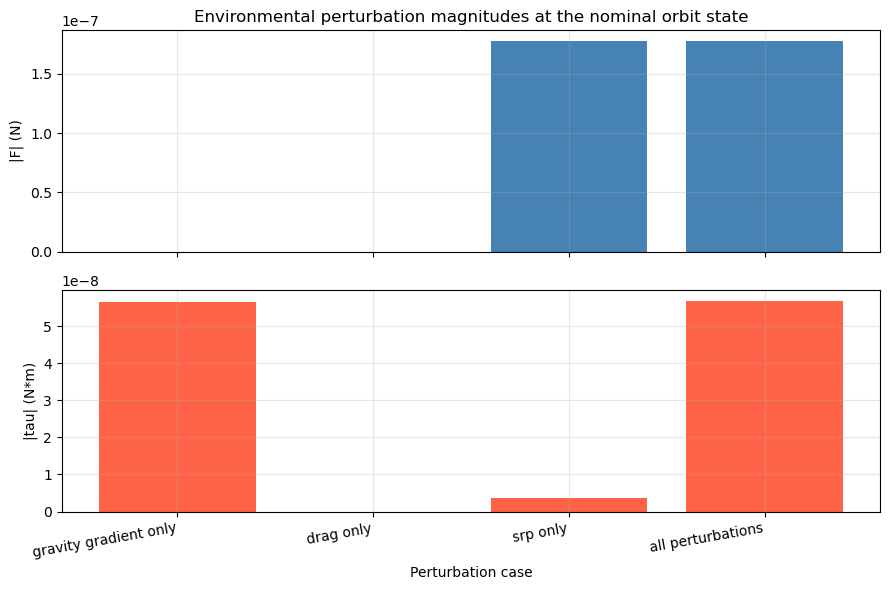

Python: None

In [27]:
cases = [
    ("gravity gradient only", (gg=true,  drag=false, srp=false)),
    ("drag only",             (gg=false, drag=true,  srp=false)),
    ("srp only",              (gg=false, drag=false, srp=true )),
    ("all perturbations",     (gg=true,  drag=true,  srp=true ))
]

torque_norms = Float64[]
force_norms = Float64[]

for (_, flags) in cases
    out = environmental_wrench(
        I_pert,
        q0_orbit,
        r0_m,
        v0_mps;
        sun_eci_m=sun_vec_eci,
        env=env,
        aero=aero,
        srp=srp,
        include_gravity_gradient=flags.gg,
        include_drag=flags.drag,
        include_srp=flags.srp
    )
    push!(force_norms, norm(out.force_eci_N))
    push!(torque_norms, norm(out.torque_body_Nm))
end

labels = [c[1] for c in cases]
x = 1:length(labels)

fig, ax = subplots(2, 1, figsize=(9, 6), sharex=true)
ax[0].bar(x, force_norms, color="steelblue")
ax[0].set_ylabel("|F| (N)")
ax[0].set_title("Environmental perturbation magnitudes at the nominal orbit state")
ax[0].grid(true, alpha=0.3)

ax[1].bar(x, torque_norms, color="tomato")
ax[1].set_ylabel("|tau| (N*m)")
ax[1].set_xticks(collect(x))
ax[1].set_xticklabels(labels, rotation=10, ha="right")
ax[1].grid(true, alpha=0.3)
ax[1].set_xlabel("Perturbation case")

fig.tight_layout()

## Orbit-Wide Torque Analysis

A single operating point does not tell us the largest disturbance the spacecraft may experience. The next blocks sample the nominal circular orbit over one full revolution and compute the gravity gradient, drag, and solar radiation pressure torques at each sample. We then extract the maximum torque magnitude for each environmental effect.

In [26]:
function circular_orbit_state(a_km, inc, raan, argp, nu)
    return coe_to_eci(a_km, 0.0, inc, raan, argp, nu)
end

function torque_history_over_orbit(I_body, q_b_to_i, a_km, inc;
        raan=0.0, argp=0.0, sun_vec_eci::SVector{3,Float64}=SVector(1.0, 0.0, 0.0),
        env=EarthEnvironment(), aero=SpacecraftAeroProperties(),
        srp=SpacecraftSRPProperties(), samples=361)

    nus = collect(range(0.0, 2pi; length=samples))
    tau_gg_hist = Vector{SVector{3,Float64}}(undef, samples)
    tau_drag_hist = Vector{SVector{3,Float64}}(undef, samples)
    tau_srp_hist = Vector{SVector{3,Float64}}(undef, samples)

    for k in eachindex(nus)
        r_km, v_kmps = circular_orbit_state(a_km, inc, raan, argp, nus[k])
        r_m = 1000.0 .* r_km
        v_mps = 1000.0 .* v_kmps

        tau_gg_hist[k] = gravity_gradient_torque(I_body, q_b_to_i, r_m)
        tau_drag_hist[k] = atmospheric_drag_torque(r_m, v_mps, q_b_to_i, aero; env=env)
        tau_srp_hist[k] = solar_radiation_pressure_torque(q_b_to_i, sun_vec_eci, srp; env=env)
    end

    return (; nus, tau_gg_hist, tau_drag_hist, tau_srp_hist)
end

function vector_norm_history(vec_hist)
    return [norm(v) for v in vec_hist]
end

function max_with_location(values, locations)
    idx = argmax(values)
    return (; value=values[idx], index=idx, location=locations[idx])
end

max_with_location (generic function with 1 method)

In [20]:
torque_data = torque_history_over_orbit(
    I_pert,
    q0_orbit,
    a_km,
    inc;
    raan=0.0,
    argp=0.0,
    sun_vec_eci=sun_vec_eci,
    env=env,
    aero=aero,
    srp=srp,
    samples=361
)

gg_norm = vector_norm_history(torque_data.tau_gg_hist)
drag_norm = vector_norm_history(torque_data.tau_drag_hist)
srp_norm = vector_norm_history(torque_data.tau_srp_hist)

gg_max = max_with_location(gg_norm, torque_data.nus)
drag_max = max_with_location(drag_norm, torque_data.nus)
srp_max = max_with_location(srp_norm, torque_data.nus)

println("Maximum gravity gradient torque magnitude [N*m] = ", gg_max.value)
println("  occurs near true anomaly [deg] = ", gg_max.location * 180 / pi)
println("Maximum atmospheric drag torque magnitude [N*m] = ", drag_max.value)
println("  occurs near true anomaly [deg] = ", drag_max.location * 180 / pi)
println("Maximum SRP torque magnitude [N*m] = ", srp_max.value)
println("  occurs near true anomaly [deg] = ", srp_max.location * 180 / pi)

perturb_labels = ["gravity gradient", "drag", "srp"]
peak_tau_vals = [gg_max.value, drag_max.value, srp_max.value]
println("\n--- ADCS4 Sec.12: peak |tau| vs RWP050 rated wheel torque ---")
println("tau_wheel_max = ", tau_wheel_max_nm, " N*m")
for k in eachindex(perturb_labels)
    r = peak_tau_vals[k] / tau_wheel_max_nm
    println("  ", perturb_labels[k], ": max |tau| = ", peak_tau_vals[k], " N*m  (~", round(r; sigdigits=4), " * tau_wheel_max)")
end

Maximum gravity gradient torque magnitude [N*m] = 8.770765926678244e-8
  occurs near true anomaly [deg] = 70.0
Maximum atmospheric drag torque magnitude [N*m] = 1.6852647132697933e-7
  occurs near true anomaly [deg] = 90.0
Maximum SRP torque magnitude [N*m] = 3.5568000000000004e-9
  occurs near true anomaly [deg] = 0.0

--- ADCS4 Sec.12: peak |tau| vs RWP050 rated wheel torque ---
tau_wheel_max = 0.006 N*m
  gravity gradient: max |tau| = 8.770765926678244e-8 N*m  (~1.462e-5 * tau_wheel_max)
  drag: max |tau| = 1.6852647132697933e-7 N*m  (~2.809e-5 * tau_wheel_max)
  srp: max |tau| = 3.5568000000000004e-9 N*m  (~5.928e-7 * tau_wheel_max)


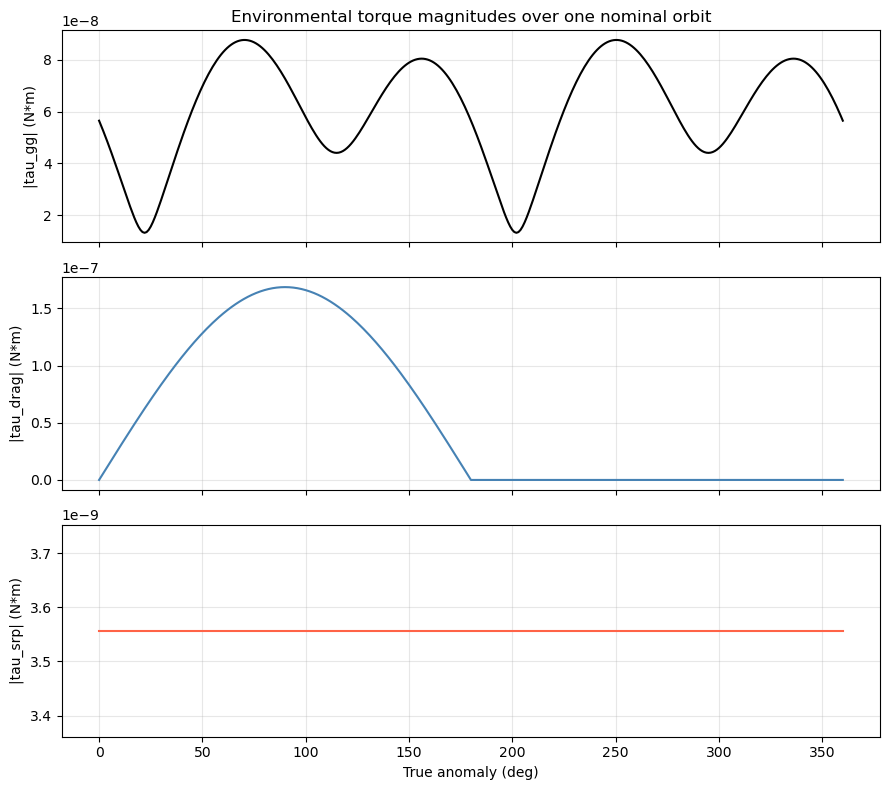

Python: None

In [29]:
nu_deg = torque_data.nus .* 180 ./ pi

fig_torque, ax_torque = subplots(3, 1, figsize=(9, 8), sharex=true)
ax_torque[0].plot(nu_deg, gg_norm, color="black")
ax_torque[0].set_ylabel("|tau_gg| (N*m)")
ax_torque[0].set_title("Environmental torque magnitudes over one nominal orbit")
ax_torque[0].grid(true, alpha=0.3)

ax_torque[1].plot(nu_deg, drag_norm, color="steelblue")
ax_torque[1].set_ylabel("|tau_drag| (N*m)")
ax_torque[1].grid(true, alpha=0.3)

ax_torque[2].plot(nu_deg, srp_norm, color="tomato")
ax_torque[2].set_ylabel("|tau_srp| (N*m)")
ax_torque[2].set_xlabel("True anomaly (deg)")
ax_torque[2].grid(true, alpha=0.3)

fig_torque.tight_layout()

## Interpretation Guide

Use the printed maximum values as disturbance-design numbers for the current nominal case. If the gravity gradient torque dominates, the spacecraft is more sensitive to its inertia distribution and nadir geometry. If the drag torque dominates, the center of pressure offset and projected area are driving the disturbance. If the SRP torque dominates, the panel normal direction, reflectivity coefficient, and center of pressure offset are the leading contributors.

## Orbit-Averaged Torque and Daily Angular Momentum Change

Peak torque is useful for sizing against the largest instantaneous disturbance, but it does not tell us whether the effect tends to cancel over an orbit or build up over time. The next blocks compute the orbit-averaged torque vector, the orbit-averaged torque magnitude, and two one-day angular momentum estimates.

The first estimate is the secular buildup, computed from the magnitude of the orbit-averaged torque vector times one day. This captures the net bias-like effect that does not cancel over repeated orbits.

The second estimate is a conservative upper bound, computed from the maximum instantaneous torque magnitude times one day. This assumes the torque could keep acting at its peak value with a perfectly aligned sign, which is generally pessimistic but useful as a bound.

In [30]:
function orbit_period_seconds(a_km; mu_km3s2=398600.4418)
    return 2pi * sqrt(a_km^3 / mu_km3s2)
end

function average_vector_over_orbit(vec_hist)
    total = zero(vec_hist[1])
    for v in vec_hist
        total += v
    end
    return total / length(vec_hist)
end

function average_scalar_over_orbit(values)
    return sum(values) / length(values)
end

function cumulative_delta_h_from_torque_profile(torque_norm_hist, orbit_period_s; day_s=86400.0)
    t_orbit = collect(range(0.0, orbit_period_s; length=length(torque_norm_hist)))
    t_day = collect(range(0.0, day_s; length=1000))
    tau_day = [torque_norm_hist[clamp(1 + floor(Int, (mod(t, orbit_period_s) / orbit_period_s) * (length(torque_norm_hist) - 1)), 1, length(torque_norm_hist))] for t in t_day]
    delta_h_day = zeros(length(t_day))
    for k in 2:length(t_day)
        dt = t_day[k] - t_day[k - 1]
        delta_h_day[k] = delta_h_day[k - 1] + 0.5 * (tau_day[k] + tau_day[k - 1]) * dt
    end
    return (; t_day, tau_day, delta_h_day, t_orbit)
end

cumulative_delta_h_from_torque_profile (generic function with 1 method)

In [31]:
orbit_period_s = orbit_period_seconds(a_km)
orbits_per_day = 86400.0 / orbit_period_s

tau_gg_avg_vec = average_vector_over_orbit(torque_data.tau_gg_hist)
tau_drag_avg_vec = average_vector_over_orbit(torque_data.tau_drag_hist)
tau_srp_avg_vec = average_vector_over_orbit(torque_data.tau_srp_hist)

tau_gg_avg_mag = average_scalar_over_orbit(gg_norm)
tau_drag_avg_mag = average_scalar_over_orbit(drag_norm)
tau_srp_avg_mag = average_scalar_over_orbit(srp_norm)

delta_h_gg_day_secular = norm(tau_gg_avg_vec) * 86400.0
delta_h_drag_day_secular = norm(tau_drag_avg_vec) * 86400.0
delta_h_srp_day_secular = norm(tau_srp_avg_vec) * 86400.0

delta_h_gg_day_upper = gg_max.value * 86400.0
delta_h_drag_day_upper = drag_max.value * 86400.0
delta_h_srp_day_upper = srp_max.value * 86400.0

println("Orbit period [s] = ", orbit_period_s)
println("Orbits per day = ", orbits_per_day)
println()
println("Gravity gradient average torque vector [N*m] = ", tau_gg_avg_vec)
println("Gravity gradient average torque magnitude over orbit [N*m] = ", tau_gg_avg_mag)
println("Gravity gradient one-day secular |Delta H| [N*m*s] = ", delta_h_gg_day_secular)
println("Gravity gradient one-day conservative upper bound |Delta H| [N*m*s] = ", delta_h_gg_day_upper)
println()
println("Atmospheric drag average torque vector [N*m] = ", tau_drag_avg_vec)
println("Atmospheric drag average torque magnitude over orbit [N*m] = ", tau_drag_avg_mag)
println("Atmospheric drag one-day secular |Delta H| [N*m*s] = ", delta_h_drag_day_secular)
println("Atmospheric drag one-day conservative upper bound |Delta H| [N*m*s] = ", delta_h_drag_day_upper)
println()
println("Solar radiation pressure average torque vector [N*m] = ", tau_srp_avg_vec)
println("Solar radiation pressure average torque magnitude over orbit [N*m] = ", tau_srp_avg_mag)
println("Solar radiation pressure one-day secular |Delta H| [N*m*s] = ", delta_h_srp_day_secular)
println("Solar radiation pressure one-day conservative upper bound |Delta H| [N*m*s] = ", delta_h_srp_day_upper)

Orbit period [s] = 5652.234202094749
Orbits per day = 15.285990797759174

Gravity gradient average torque vector [N*m] = [4.707762647469457e-10, 2.2989440878383473e-8, 2.438400569580915e-9]
Gravity gradient average torque magnitude over orbit [N*m] = 6.037411518384474e-8
Gravity gradient one-day secular |Delta H| [N*m*s] = 0.0019978434361875566
Gravity gradient one-day conservative upper bound |Delta H| [N*m*s] = 0.0075779417606500026

Atmospheric drag average torque vector [N*m] = [0.0, 1.8784662166460328e-25, 4.201490974910817e-8]
Atmospheric drag average torque magnitude over orbit [N*m] = 5.3202375347925744e-8
Atmospheric drag one-day secular |Delta H| [N*m*s] = 0.0036300882023229462
Atmospheric drag one-day conservative upper bound |Delta H| [N*m*s] = 0.014560687122651014

Solar radiation pressure average torque vector [N*m] = [0.0, 0.0, -3.5568000000000322e-9]
Solar radiation pressure average torque magnitude over orbit [N*m] = 3.5568000000000004e-9
Solar radiation pressure one-d

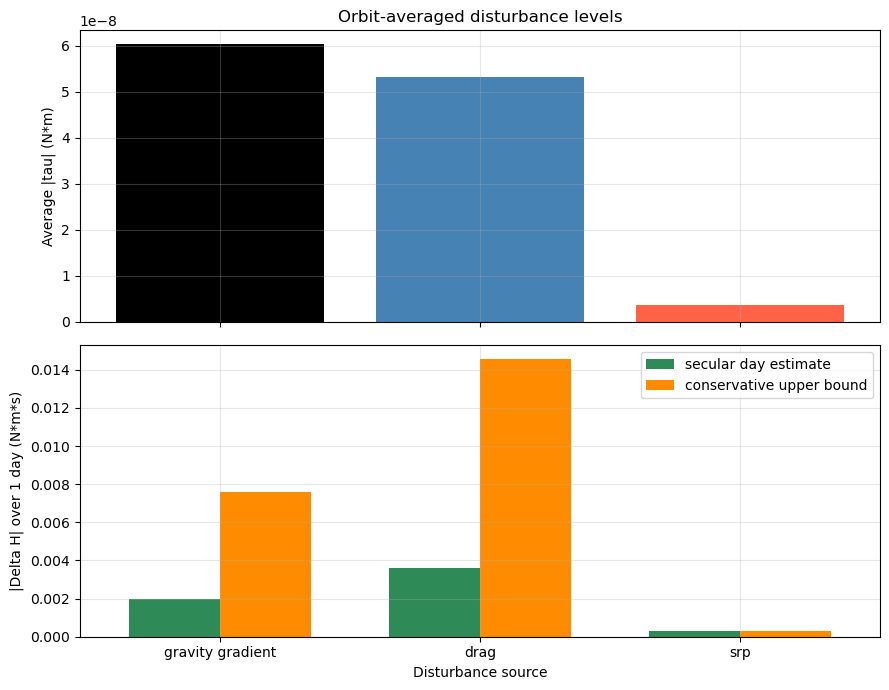

Python: None

In [23]:
summary_labels = ["gravity gradient", "drag", "srp"]
avg_mag_values = [tau_gg_avg_mag, tau_drag_avg_mag, tau_srp_avg_mag]
secular_day_values = [delta_h_gg_day_secular, delta_h_drag_day_secular, delta_h_srp_day_secular]
upper_day_values = [delta_h_gg_day_upper, delta_h_drag_day_upper, delta_h_srp_day_upper]
x = 1:length(summary_labels)

fig_avg, ax_avg = subplots(2, 1, figsize=(9, 7), sharex=true)
ax_avg[0].bar(x, avg_mag_values, color=["black", "steelblue", "tomato"])
ax_avg[0].set_ylabel("Average |tau| (N*m)")
ax_avg[0].set_title("Orbit-averaged disturbance levels")
ax_avg[0].grid(true, alpha=0.3)

bar_width = 0.35
ax_avg[1].bar((x .- bar_width ./ 2), secular_day_values, width=bar_width, label="secular day estimate", color="seagreen")
ax_avg[1].bar((x .+ bar_width ./ 2), upper_day_values, width=bar_width, label="conservative upper bound", color="darkorange")
ax_avg[1].set_ylabel("|Delta H| over 1 day (N*m*s)")
ax_avg[1].set_xticks(collect(x))
ax_avg[1].set_xticklabels(summary_labels)
ax_avg[1].legend(loc="upper right")
ax_avg[1].grid(true, alpha=0.3)
ax_avg[1].set_xlabel("Disturbance source")

fig_avg.tight_layout()

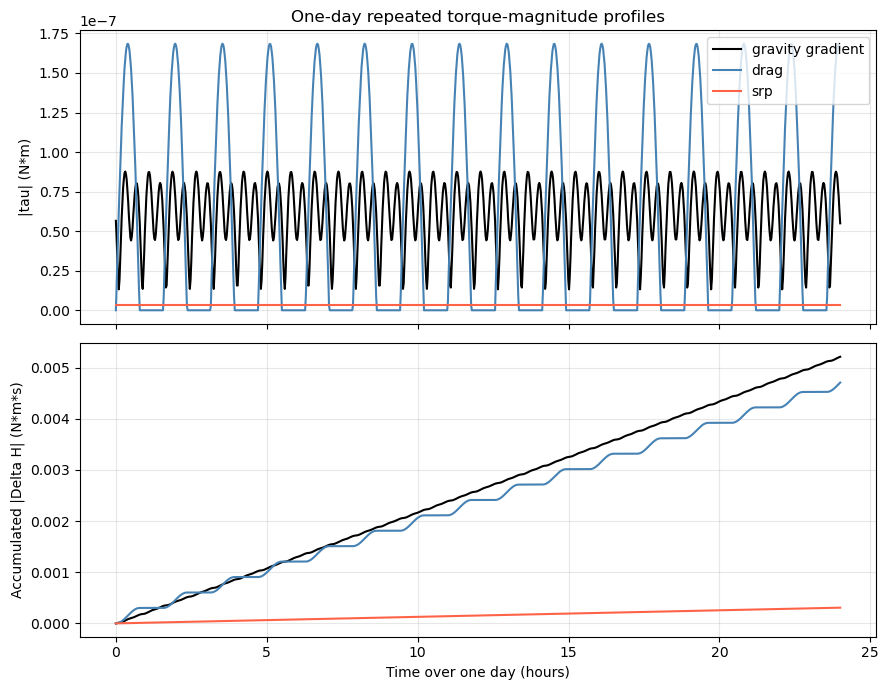

Python: None

In [24]:
gg_day = cumulative_delta_h_from_torque_profile(gg_norm, orbit_period_s)
drag_day = cumulative_delta_h_from_torque_profile(drag_norm, orbit_period_s)
srp_day = cumulative_delta_h_from_torque_profile(srp_norm, orbit_period_s)

fig_day, ax_day = subplots(2, 1, figsize=(9, 7), sharex=true)
ax_day[0].plot(gg_day.t_day ./ 3600.0, gg_day.tau_day, label="gravity gradient", color="black")
ax_day[0].plot(drag_day.t_day ./ 3600.0, drag_day.tau_day, label="drag", color="steelblue")
ax_day[0].plot(srp_day.t_day ./ 3600.0, srp_day.tau_day, label="srp", color="tomato")
ax_day[0].set_ylabel("|tau| (N*m)")
ax_day[0].set_title("One-day repeated torque-magnitude profiles")
ax_day[0].legend(loc="upper right")
ax_day[0].grid(true, alpha=0.3)

ax_day[1].plot(gg_day.t_day ./ 3600.0, gg_day.delta_h_day, label="gravity gradient", color="black")
ax_day[1].plot(drag_day.t_day ./ 3600.0, drag_day.delta_h_day, label="drag", color="steelblue")
ax_day[1].plot(srp_day.t_day ./ 3600.0, srp_day.delta_h_day, label="srp", color="tomato")
ax_day[1].set_ylabel("Accumulated |Delta H| (N*m*s)")
ax_day[1].set_xlabel("Time over one day (hours)")
ax_day[1].grid(true, alpha=0.3)

fig_day.tight_layout()

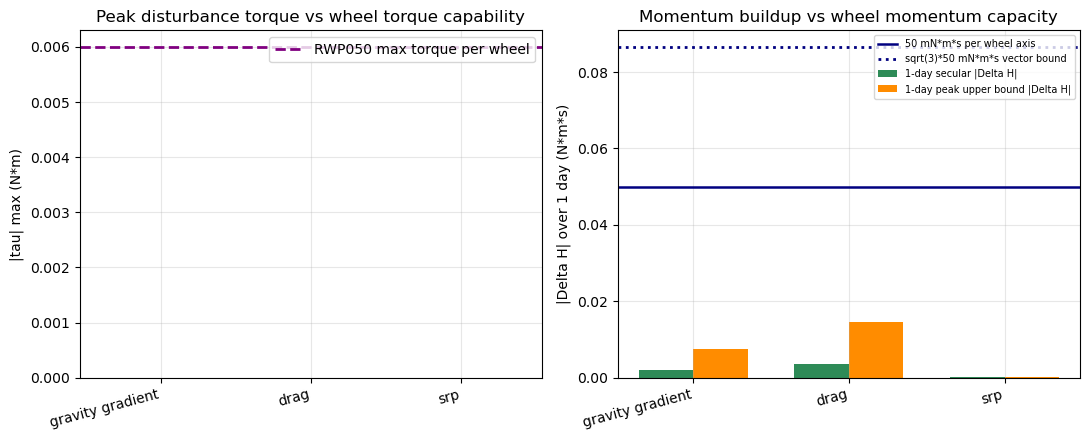

Python: None

In [33]:
# ADCS4 Section 12 sizing: compare disturbances to RWP050 wheel torque / momentum
fig_s12, axs = subplots(1, 2, figsize=(11, 4.5))
xpos = 1:3
bw = 0.35

axs[0].bar(xpos, peak_tau_vals, color=["black", "steelblue", "tomato"])
axs[0].axhline(tau_wheel_max_nm, color="purple", linestyle="--", linewidth=2, label="RWP050 max torque per wheel")
axs[0].set_yscale("log")
flo = minimum(peak_tau_vals)
axs[0].set_ylim(flo > 0 ? (0.3 * flo) : (1e-12), tau_wheel_max_nm * 4)
axs[0].set_xticks(collect(xpos))
axs[0].set_xticklabels(perturb_labels, rotation=15, ha="right")
axs[0].set_ylabel("|tau| max (N*m), log scale")
axs[0].set_title("Peak disturbance torque vs wheel torque capability")
axs[0].legend(loc="upper right")
axs[0].grid(true, alpha=0.3, which="both")

sec = [delta_h_gg_day_secular, delta_h_drag_day_secular, delta_h_srp_day_secular]
upb = [delta_h_gg_day_upper, delta_h_drag_day_upper, delta_h_srp_day_upper]
axs[1].bar(xpos .- bw ./ 2, sec, width=bw, label="1-day secular |Delta H|", color="seagreen")
axs[1].bar(xpos .+ bw ./ 2, upb, width=bw, label="1-day peak upper bound |Delta H|", color="darkorange")
axs[1].axhline(h_wheel_max_nms_per_axis, color="navy", linestyle="-", linewidth=1.8, label="50 mN*m*s per wheel axis")
axs[1].axhline(h_wheel_sphere_bound_nms, color="navy", linestyle=":", linewidth=2, label="sqrt(3)*50 mN*m*s vector bound")
axs[1].set_xticks(collect(xpos))
axs[1].set_xticklabels(perturb_labels, rotation=15, ha="right")
axs[1].set_ylabel("|Delta H| over 1 day (N*m*s)")
axs[1].set_title("Momentum buildup vs wheel momentum capacity")
axs[1].legend(loc="upper right", fontsize=7)
axs[1].grid(true, alpha=0.3)
fig_s12.tight_layout()


## Actuator and Control-System Implications

The environmental torques matter in two distinct ways: **instantaneous rejection** scales with peak \(|\boldsymbol{\tau}|\); **long-term momentum management** scales with secular or quasi-biases in disturbance torque versus **wheel saturation** and **maximum motor torque**.

The previous figure compares disturbances to **ADCS4 Section 12** **RWP050** limits (6 mN·m, 50 mN·m·s per axis). Magnetorquer-only dumping is not sized here (**\(\boldsymbol{\tau}_c \perp \mathbf{B}\)**; effectiveness depends on orbit and attitude \(\mathbf{B}(t)\) in body coordinates).

The next blocks print **estimated dump-interval style** ratios using **`H_r`** (safe-mode gyrostat reference), **per-wheel-axis** momentum **50 mN·m·s**, and a **\(\sqrt{3}\)-scaled** Euclidean bound for simultaneous triaxial saturation—not a physics limit, only a shorthand budget for reports.

In [34]:
function dump_interval_days(momentum_capacity, daily_delta_h)
    if daily_delta_h <= 0.0
        return Inf
    end
    return momentum_capacity / daily_delta_h
end

secular_day_values = [delta_h_gg_day_secular, delta_h_drag_day_secular, delta_h_srp_day_secular]
upper_day_values = [delta_h_gg_day_upper, delta_h_drag_day_upper, delta_h_srp_day_upper]
max_torque_values = [gg_max.value, drag_max.value, srp_max.value]
avg_torque_values = [tau_gg_avg_mag, tau_drag_avg_mag, tau_srp_avg_mag]

dominant_peak_idx = argmax(max_torque_values)
dominant_secular_idx = argmax(secular_day_values)

peak_source = summary_labels[dominant_peak_idx]
secular_source = summary_labels[dominant_secular_idx]

# Gyrostat safe-mode reference
dump_days_Hr_secular = [dump_interval_days(H_r, x) for x in secular_day_values]
dump_days_Hr_upper = [dump_interval_days(H_r, x) for x in upper_day_values]
# ADCS4 RWP050: per-axis wheel saturation vs daily momentum growth
dump_days_wheel_axis_secular = [dump_interval_days(h_wheel_max_nms_per_axis, x) for x in secular_day_values]
dump_days_wheel_axis_upper = [dump_interval_days(h_wheel_max_nms_per_axis, x) for x in upper_day_values]
dump_days_sphere_secular = [dump_interval_days(h_wheel_sphere_bound_nms, x) for x in secular_day_values]
dump_days_sphere_upper = [dump_interval_days(h_wheel_sphere_bound_nms, x) for x in upper_day_values]

dump_orbits_Hr_secular = dump_days_Hr_secular .* orbits_per_day
dump_orbits_Hr_upper = dump_days_Hr_upper .* orbits_per_day

println("--- Momentum reference capacities [N*m*s]")
println("H_r safe-mode rotor reference = ", H_r)
println("h_wheel_max per wheel axis (RWP050) = ", h_wheel_max_nms_per_axis)
println("sqrt(3)*h_wheel_max spherical bound |rho| = ", h_wheel_sphere_bound_nms)
println()
println("Dominant peak-torque disturbance source = ", peak_source)
println("Dominant secular momentum-accumulation source = ", secular_source)
println()
for k in eachindex(summary_labels)
    println(summary_labels[k], ":")
    println("  average torque magnitude over orbit [N*m] = ", avg_torque_values[k])
    println("  maximum torque magnitude [N*m] = ", max_torque_values[k],
        " (~", round(max_torque_values[k] / tau_wheel_max_nm; sigdigits=5), " * tau_wheel_max)")
    println("  dump cadence vs H_r secular [days, orbits]: ", dump_days_Hr_secular[k], ", ", dump_orbits_Hr_secular[k])
    println("  dump cadence vs H_r peak upper bd [days, orbits]: ", dump_days_Hr_upper[k], ", ", dump_orbits_Hr_upper[k])
    println("  vs 50 mN*m*s per-axis secular [days]: ", dump_days_wheel_axis_secular[k])
    println("  vs 50 mN*m*s per-axis peak upper bd [days]: ", dump_days_wheel_axis_upper[k])
    println("  vs sqrt(3)*50 secular [days]: ", dump_days_sphere_secular[k])
    println()
end

# Keep legacy names expected by plotting cell below
dump_days_secular = dump_days_Hr_secular
dump_days_upper = dump_days_Hr_upper
dump_orbits_secular = dump_orbits_Hr_secular
dump_orbits_upper = dump_orbits_Hr_upper

--- Momentum reference capacities [N*m*s]
H_r safe-mode rotor reference = 0.11303443327953495
h_wheel_max per wheel axis (RWP050) = 0.05
sqrt(3)*h_wheel_max spherical bound |rho| = 0.08660254037844387

Dominant peak-torque disturbance source = drag
Dominant secular momentum-accumulation source = drag

gravity gradient:
  average torque magnitude over orbit [N*m] = 6.037411518384474e-8
  maximum torque magnitude [N*m] = 8.770765926678244e-8 (~1.4618e-5 * tau_wheel_max)
  dump cadence vs H_r secular [days, orbits]: 56.57822391490107, 864.8542101167359
  dump cadence vs H_r peak upper bd [days, orbits]: 14.916244654516763, 228.0095785260677
  vs 50 mN*m*s per-axis secular [days]: 25.02698614632885
  vs 50 mN*m*s per-axis peak upper bd [days]: 6.5980976865822765
  vs sqrt(3)*50 secular [days]: 43.34801156576398

drag:
  average torque magnitude over orbit [N*m] = 5.3202375347925744e-8
  maximum torque magnitude [N*m] = 1.6852647132697933e-7 (~2.8088e-5 * tau_wheel_max)
  dump cadence vs H_

3-element Vector{Float64}:
  228.0095785260677
  118.66495670063627
 5622.522048731168

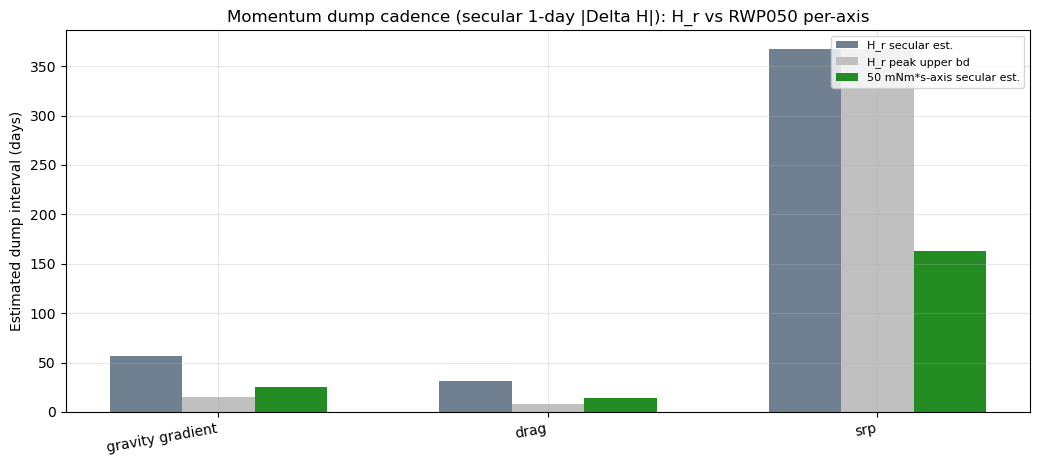

Python: None

In [35]:
fig_dump, ax_dump = subplots(1, 1, figsize=(10.5, 4.75))
bw = 0.22
x = 1:length(summary_labels)

ax_dump.bar((x .- bw), dump_days_Hr_secular, width=bw, label="H_r secular est.", color="slategray")
ax_dump.bar(x, dump_days_Hr_upper, width=bw, label="H_r peak upper bd", color="silver")
ax_dump.bar((x .+ bw), dump_days_wheel_axis_secular, width=bw, label="50 mNm*s-axis secular est.", color="forestgreen")

ax_dump.set_xticks(collect(x))
ax_dump.set_xticklabels(summary_labels, rotation=10, ha="right")
ax_dump.set_ylabel("Estimated dump interval (days)")
ax_dump.set_title("Momentum dump cadence (secular 1-day |Delta H|): H_r vs RWP050 per-axis")
ax_dump.legend(loc="upper right", fontsize=8)
ax_dump.grid(true, alpha=0.3)
fig_dump.tight_layout()

The disturbance analysis sizes both **transient** authority (peak \(|\boldsymbol{\tau}|\) vs **RWP050 6 mN·m**) and **cumulative** unloading (estimated **1-day** \(|\Delta\mathbf H|\) vs **50 mN·m·s** per wheel axis, together with **`H_r`** as a gyrostat-side reference).

If peak torques routinely exceed commanded wheel torque, control cannot fully reject the disturbance instantaneously—bandwidth, redundancy, or geometry (e.g. CP offset reduction) matters. If estimated dump intervals versus **wheel saturation** are short versus operations, schedule **magnetorquer desaturation** (subject to **\(\boldsymbol{\tau}_c\perp \mathbf B\)**) or increase allowable stored momentum via mission rules.

## Coupled multi-orbit propagation (HW4 §2)

**Model choice (LEO):** dynamics use **gravity gradient torque** and **atmospheric drag** (force in translation + torque from CP offset). **SRP is omitted** in the propagator: at ~480 km, **aerodynamic** effects dominate **radiation pressure** for typical area/mass, matching the earlier torque budget.

**State:** \([r;v,q,\omega]\) in **km / km/s** with **gyrostat** \(\mathbf{h}_r = H_r \hat{\mathbf{e}}\). Translation: two-body + **J2** + **\( \mathbf{F}_{\mathrm{drag}}/m\)** from `environmental_perturbations.jl`. Attitude: \(\mathbf{I}\dot{\boldsymbol\omega} = \boldsymbol\tau_{\mathrm{env}} - \boldsymbol\omega \times (\mathbf{I}\boldsymbol\omega + \mathbf{h}_r)\).

**Scenarios** (same ICs): **baseline** (no env wrench), **+GG only**, **+drag only** (no GG torque), **+GG+drag** (full LEO env). Compare **Sun-pointing error** and coarse **orbital radius** over **several** periods.

In [ ]:
Random.seed!(54321)
n_orbits_coupled = 5
t_end_coupled = n_orbits_coupled * orbit_period_s

delta_w_p = 0.01 * omega_des
xis = SVector(1.0, 0.0, 0.0)
xisn = normalize(xis - dot(xis, e_panel) * e_panel)
w0_coupled = w_des + delta_w_p * xisn

x0_coupled = zeros(13)
x0_coupled[1:3] .= r0_km
x0_coupled[4:6] .= v0_kmps
x0_coupled[7:10] .= q0_orbit
x0_coupled[11:13] .= w0_coupled

e_hat = normalize(SVector{3,Float64}(e_panel))

scenario_defs = [
    ("A baseline: J2+two-body, no env wrench", false, false),
    ("B +gravity gradient only", true, false),
    ("C +drag force/torque only", false, true),
    ("D +GG + drag (LEO env model)", true, true),
]

sols_env = Dict{String,Any}()
for (label, gg, dr) in scenario_defs
    params = OrbitGyrostatEnvParams(;
        I = I_pert,
        H_r = H_r,
        e = e_hat,
        env = env,
        aero = aero,
        include_gg = gg,
        include_drag = dr,
    )
    sol = integrate_orbit_gyrostat_env!(
        x0_coupled, params;
        tspan=(0.0, t_end_coupled),
        saveat=60.0,
        reltol=1e-8,
        abstol=1e-11,
    )
    sols_env[label] = sol
    println(label, "  ->  steps saved=", length(sol.t), ",  tf[h]=", round(sol.t[end] / 3600; digits=3))
end

In [ ]:
function radius_km_from_sol(sol)
    return [hypot(u[1], u[2], u[3]) for u in sol.u]
end

fig_c, ax_c = subplots(2, 1, figsize=(11, 7.5), sharex=true)
for (label, _, _) in scenario_defs
    sol = sols_env[label]
    th = sol.t ./ 3600.0
    pe_deg = pointing_error(sol, e_panel, sun_vec_eci)
    ax_c[0].plot(th, pe_deg; label=label)
end
ax_c[0].set_ylabel("Sun pointing error (deg)")
ax_c[0].set_title("Coupled propagation: $(n_orbits_coupled) orbits — same ICs, env toggles")
ax_c[0].legend(loc="best", fontsize=7)
ax_c[0].grid(true, alpha=0.35)

for (label, _, _) in scenario_defs
    sol = sols_env[label]
    th = sol.t ./ 3600.0
    ax_c[1].plot(th, radius_km_from_sol(sol); label=label)
end
ax_c[1].set_ylabel("|r| (km)")
ax_c[1].set_xlabel("Time (h)")
ax_c[1].grid(true, alpha=0.35)

fig_c.tight_layout()

## Notes for the Next Step

**Done here:** coupled **orbit–gyrostat** propagation in **§ Coupled multi-orbit propagation** integrates **J2 + two-body**, optional **gravity-gradient torque**, optional **LEO drag** (no SRP), with cases **A–D** comparing toggles over **several orbits**.

**Further improvements (optional):** add **SRP** back for high-orbit comparisons; use time-varying Sun / eclipse; tighter **saveat** / tolerances for publication plots; **combine** disturbance torques vectorially in the **momentum-buildup** section rather than per-source isolation.